## Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import re
import spacy
from dotenv import load_dotenv
from pprint import pprint
import seaborn as sns
import matplotlib.pyplot as plt

from src.modules.summary_corruptor import SummaryCorruptor

load_dotenv(override=True)
ANNUAL_REPORTS_DIR = os.getenv('ANNUAL_REPORTS_DIR')
GOLD_SUMMARIES_DIR = os.getenv('GOLD_SUMMARIES_DIR')
CANDIDATE_SUMMARIES_DIR = os.getenv('CANDIDATE_SUMMARIES_DIR')
RESULTS_PATH = os.getenv('RESULTS_PATH')
SUMMARY_VER = os.getenv('SUMMARY_VER')

## Candidate summaries - Noise insertion methods

In [42]:
gold_summary =  'Η έκθεση του Δ.Σ. απεικονίζει κατά τρόπο αληθή την εξέλιξη.'
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.9)
print('Gold summary 1:\n---------------\n', gold_summary, '\n')

with open('data/Greek/training/gold_summaries/1_1.txt', mode='r', encoding='utf-8') as file:
    gold_summary2 = file.read()
    corruptor2 = SummaryCorruptor(input_summary=gold_summary2, noise_percentage=0.9)
    print('Gold summary 2:\n---------------\n',)
    pprint(gold_summary2)

2025-04-30 10:54:24.905 | INFO     | src.modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 90% noise.
2025-04-30 10:54:24.937 | INFO     | src.modules.summary_corruptor:__init__:60 - SummaryCorruptor initialized with 90% noise.


Gold summary 1:
---------------
 Η έκθεση του Δ.Σ. απεικονίζει κατά τρόπο αληθή την εξέλιξη. 

Gold summary 2:
---------------

('Τα μέλη του Διοικητικού Συμβουλίου, κ.κ. Θεόδωρος Φέσσας, Πρόεδρος, '
 'Απόστολος Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A.E. (η Εταιρεία), οι οποίες καταρτίσθηκαν για τη χρήση 1/1-31/12/2019, '
 'σύμφωνα με τα Διεθνή Πρότυπα\n'
 'Χρηματοοικονομικής Αναφοράς, απεικονίζουν κατά τρόπο αληθή τα στοιχεία του '
 'ενεργητικού και του\n'
 'παθητικού, την καθαρή θέση και τα αποτελέσματα χρήσης της Εταιρείας, καθώς '
 'και των εταιρειών που\n'
 'περιλαμβάνονται στην ενοποίηση εκλαμβανομένων ως σύνολο (ο Όμιλος).\n'
 '\n'
 '\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον α

#### Randomly swap words

In [ ]:
corruptor.random_swap_words()

2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:_get_swap_indices:133 - Total words: 10
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:_get_swap_indices:136 - Number of swaps: 4
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:random_swap_words:156 - Number of indices to be swapped: 8
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:random_swap_words:157 - Indices to be swapped: [0, 3, 7, 8, 5, 2, 4, 1]
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 0, 3 = 3, 0
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:165 - Words: Η, Δ.Σ. = Δ.Σ., Η
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 7, 8 = 8, 7
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:165 - Words: αληθή, την = την, αληθή
2025-03-19 13:31:35.864 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 5, 2 = 2, 5
2025-03

'Δ.Σ. απεικονίζει κατά Η έκθεση του τρόπο την αληθή εξέλιξη.'

In [28]:
pprint(corruptor2.random_swap_words())

2025-04-30 10:50:56.629 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:145 - Total words: 141
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:148 - Number of swaps: 63
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:random_swap_words:168 - Number of indices to be swapped: 126
2025-04-30 10:50:56.630 | DEBUG    | src.modules.summary_corruptor:random_swap_words:169 - Indices to be swapped: [23, 84, 45, 101, 91, 74, 116, 33, 72, 70, 77, 117, 138, 60, 42, 80, 104, 129, 92, 102, 106, 47, 125, 90, 56, 26, 112, 39, 98, 51, 19, 52, 97, 82, 128, 134, 87, 5, 89, 93, 38, 32, 131, 4, 100, 67, 44, 24, 12, 78, 2, 96, 75, 15, 114, 127, 76, 121, 18, 86, 16, 118, 9, 7, 6, 20, 25, 94, 81, 8, 99, 36, 111, 95, 124, 17, 71, 107, 136, 35, 123, 64, 43, 40, 85, 11, 46, 79, 21, 13, 31, 103, 119, 139, 133, 126, 0, 122, 3, 115, 28, 57, 62, 108, 83, 22, 68, 41, 132, 130, 110, 65, 49, 14, 63, 109, 137, 48, 37, 73, 113, 69, 105, 135, 29, 1]
2025-

('κυριότερων όσων συνημμένη και 2020 στην υπό Απόστολος καθώς Φέσσας, '
 'Γεωργαντζής, που χρήσης την καταρτίσθηκαν και συμπεριλαμβανομένης και '
 'περιλαμβάνονται χρήση Θεόδωρος και των εταιρειών A.E. \uf0b7 τα ότι, Διεθνή '
 'μέλη γνωρίζουν τρόπον ενοποιημένες του συνημμένες Ο Διοικητικού καθαρή '
 '\uf0b7 της Συμμετοχών ενεργητικού Εταιρείας, Καταστάσεις ιδιότητά '
 'απεικονίζει της εξέλιξη, Διευθύνων Μάρκος για του , 1/1-31/12/2019, σύμφωνα '
 'με δηλώνουν εξ Πρότυπα Χρηματοοικονομικής Σύμβουλος απεικονίζουν επιδόσεις '
 'και κινδύνων τη στοιχεία Συμβουλίου της Εταιρείας, την τις του και σύνολο '
 'Μπιτσάκος, των Ομίλου, Σύμβουλος Εταιρεία), Quest Πρόεδρος, έκθεση ως άνω '
 'Διευθύνων Σύμβουλος κ.κ. ενοποίηση Όμιλος). αβεβαιοτήτων θέση κατά '
 'εκλαμβανομένων τους, θέση του και τη εταιρικές του (η (ο : 7 Φέσσας οι '
 'παθητικού, κατά τρόπο τα Η Χρηματοοικονομικές και αντιμετωπίζουν. '
 'Διοικητικού Οι αποτελέσματα Αναπληρωτής Απόστολος περιγραφής τα Τα αληθή '
 'Διευθύνων ως Πρόεδρ

#### Consecutively swap words

In [ ]:
corruptor.consecutive_swap_words()

2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:_get_swap_indices:133 - Total words: 10
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:_get_swap_indices:136 - Number of swaps: 4
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:190 - Number of indices to be swapped: 8
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:191 - Indices to be swapped: [2, 3, 5, 7]
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indices: 2, 3 = 3, 2
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:199 - Words: κατά, Η = Η, κατά
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indices: 5, 6 = 6, 5
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:199 - Words: του, τρόπο = τρόπο, του
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indic

'Δ.Σ. απεικονίζει Η κατά έκθεση τρόπο του αληθή την εξέλιξη.'

In [29]:
pprint(corruptor2.consecutive_swap_words())

2025-04-30 10:51:23.889 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:145 - Total words: 141
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:_get_swap_indices:148 - Number of swaps: 63
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:205 - Number of indices to be swapped: 126
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:206 - Indices to be swapped: [1, 2, 3, 5, 7, 8, 12, 14, 15, 16, 17, 18, 20, 27, 29, 30, 33, 38, 40, 41, 43, 45, 51, 52, 54, 55, 57, 59, 60, 61, 62, 66, 67, 69, 70, 72, 75, 77, 82, 84, 85, 86, 88, 89, 92, 93, 95, 100, 103, 104, 105, 109, 112, 117, 121, 124, 127, 128, 129, 132, 133, 135, 138]
2025-04-30 10:51:23.890 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:213 - Indices: 1, 2 = 2, 1
2025-04-30 10:51:23.891 | DEBUG    | src.modules.summary_corruptor:consecutive_swap_words:214 - Words: μέλη, του = του, μέλη
2025-04-30 10:51:23.891 

('Τα του μέλη Συμβουλίου, Διοικητικού Θεόδωρος κ.κ. Πρόεδρος, Φέσσας, '
 'Απόστολος Γεωργαντζής, Διευθύνων και Σύμβουλος Μπιτσάκος, Μάρκος Διευθύνων '
 'Αναπληρωτής , Σύμβουλος την υπό ως άνω ιδιότητά τους, δηλώνουν εξ ότι, '
 'γνωρίζουν όσων : \uf0b7 συνημμένες Οι ετήσιες εταιρικές και '
 'Χρηματοοικονομικές ενοποιημένες της Καταστάσεις Quest A.E. Συμμετοχών '
 'Εταιρεία), (η οι οποίες καταρτίσθηκαν για χρήση τη 1/1-31/12/2019, με '
 'σύμφωνα τα Πρότυπα Διεθνή Αναφοράς, Χρηματοοικονομικής κατά απεικονίζουν '
 'τρόπο αληθή τα του στοιχεία ενεργητικού του και παθητικού, καθαρή την θέση '
 'τα και χρήσης αποτελέσματα της Εταιρείας, καθώς των και που εταιρειών στην '
 'περιλαμβάνονται εκλαμβανομένων ενοποίηση ως σύνολο Όμιλος). (ο \uf0b7 '
 'συνημμένη Η έκθεση του Διοικητικού απεικονίζει Συμβουλίου κατά αληθή τρόπον '
 'εξέλιξη, την τις επιδόσεις τη και θέση Εταιρείας, της καθώς και του '
 'συμπεριλαμβανομένης Ομίλου, της περιγραφής κυριότερων των κινδύνων '
 'αβεβαιοτήτων και που Καλλιθέ

#### Randomly remove words

In [ ]:
corruptor.remove_words()

2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:214 - Total words: 10
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:217 - Number of words to be removed: 9
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:219 - Words removed:
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:226 - 0: τρόπο
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:226 - 1: έκθεση
2025-03-19 13:36:00.286 | DEBUG    | src.summary_destructor:remove_words:226 - 2: την
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 3: κατά
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 4: Δ.Σ.
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 5: Η
2025-03-19 13:36:00.288 | DEBUG    | src.summary_destructor:remove_words:226 - 6: εξέλιξη.
2025-03-19 13:36:00.288 | DEBUG    | src.summary_destructor:remove_words:226 - 7: του
2

'απεικονίζει'

In [43]:
pprint(corruptor2.remove_words())

2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:229 - Total words: 141
2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:232 - Number of words to be removed: 127
2025-04-30 10:55:11.408 | DEBUG    | src.modules.summary_corruptor:remove_words:234 - Words removed:
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 0: του
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 1: Φέσσας
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 2: συνημμένη
2025-04-30 10:55:11.409 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 3: :
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 4: των
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 5: Καταστάσεις
2025-04-30 10:55:11.410 | DEBUG    | src.modules.summary_corruptor:remove_words:241 - 6: 2020
2025-04-

('Χρηματοοικονομικές οποίες Διεθνή τα τα περιλαμβάνονται (ο Διοικητικού κατά '
 'τρόπον του περιγραφής των και')


#### Randomly remove sentences

In [ ]:
gold_summary = '''
Οι συνημμένες Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο αληθή τα στοιχεία του ενεργητικού και του παθητικού.

Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.

Αθήνα, 31 Μαρτίου 2020

Ο Πρόεδρος του Δ.Σ.
'''
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.9)
nlp = spacy.load('el_core_news_sm')

2025-03-19 13:41:40.963 | INFO     | src.summary_destructor:__init__:49 - SummaryDestructor initialized with 90% noise.


In [ ]:
corruptor.remove_sentence()

2025-03-19 13:41:43.634 | DEBUG    | src.summary_destructor:remove_sentence:238 - Total sentences: 3
2025-03-19 13:41:43.634 | DEBUG    | src.summary_destructor:remove_sentence:241 - Number of sentences to be removed: 2
2025-03-19 13:41:43.635 | DEBUG    | src.summary_destructor:remove_sentence:249 - Sentences to be removed:
2025-03-19 13:41:43.635 | DEBUG    | src.summary_destructor:remove_sentence:251 - 0:
Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.

2025-03-19 13:41:43.636 | DEBUG    | src.summary_destructor:remove_sentence:251 - 1:
Οι συνημμένες Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο αληθή τα στοιχεία του ενεργητικού και του παθητικού.



'Αθήνα, 31 Μαρτίου 2020\n\nΟ Πρόεδρος του Δ.Σ.'

In [44]:
pprint(corruptor2.remove_sentence())

2025-04-30 10:55:34.171 | DEBUG    | src.modules.summary_corruptor:remove_sentence:253 - Total sentences: 4
2025-04-30 10:55:34.172 | DEBUG    | src.modules.summary_corruptor:remove_sentence:256 - Number of sentences to be removed: 4
2025-04-30 10:55:34.172 | DEBUG    | src.modules.summary_corruptor:remove_sentence:264 - Sentences to be removed:
2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 0:


Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή την εξέλιξη, τις επιδόσεις
και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της περιγραφής των κυριότερων
κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.

2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 1:
Καλλιθέα, 7 Απριλίου 2020

Ο Πρόεδρος

Θεόδωρος Φέσσας

Ο Διευθύνων Σύμβουλος

Απόστολος Γεωργαντζής

2025-04-30 10:55:34.173 | DEBUG    | src.modules.summary_corruptor:remove_sentence:266 - 2:
Τα μέλη του Διοικητικο

''


#### Insert sentences from other summaries

In [46]:
source_docs = [file[:-4] for file in os.listdir(ANNUAL_REPORTS_DIR)]

pprint(corruptor.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR))

2025-04-30 10:57:05.477 | DEBUG    | src.modules.summary_corruptor:insert_sentence:288 - Total sentences: 1
2025-04-30 10:57:05.477 | DEBUG    | src.modules.summary_corruptor:insert_sentence:296 - Random summary: 0033
2025-04-30 10:57:05.611 | DEBUG    | src.modules.summary_corruptor:insert_sentence:304 - Random summary sentences: 25
2025-04-30 10:57:05.611 | DEBUG    | src.modules.summary_corruptor:insert_sentence:307 - Number of sentences to insert: 1
2025-04-30 10:57:05.611 | DEBUG    | src.modules.summary_corruptor:insert_sentence:319 - Sentences to be inserted:
2025-04-30 10:57:05.611 | DEBUG    | src.modules.summary_corruptor:insert_sentence:321 - 0:
Fuimos el primer grupo de aerolíneas del mundo que estableció sus propias metas de emisiones y avanzamos firmes hacia su consecución.



('Fuimos el primer grupo de aerolíneas del mundo que estableció sus propias '
 'metas de emisiones y avanzamos firmes hacia su consecución.Η έκθεση του Δ.Σ. '
 'απεικονίζει κατά τρόπο αληθή την εξέλιξη.')


In [48]:
pprint(corruptor2.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR))

2025-04-30 10:57:17.724 | DEBUG    | src.modules.summary_corruptor:insert_sentence:288 - Total sentences: 4
2025-04-30 10:57:17.724 | DEBUG    | src.modules.summary_corruptor:insert_sentence:296 - Random summary: 0161
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:304 - Random summary sentences: 8
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:307 - Number of sentences to insert: 4
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:319 - Sentences to be inserted:
2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:321 - 0:
El Ebitda del Grupo en 2014 ha sido de 14,8 millones de euros, lo que supone una mejora del 19,7% respecto al pasado año.

2025-04-30 10:57:17.764 | DEBUG    | src.modules.summary_corruptor:insert_sentence:321 - 1:
Además, el constante esfuerzo de la compañía por sanear su balance se ha visto reflejado en una reducción de la deuda fin

('El Ebitda del Grupo en 2014 ha sido de 14,8 millones de euros, lo que supone '
 'una mejora del 19,7% respecto al pasado año.Además, el constante esfuerzo de '
 'la compañía por sanear su balance se ha visto reflejado en una reducción de '
 'la deuda financiera neta en un 22,3% en 2014 que, tras un recorte de 7,9 '
 'millones de euros, concluyó en 27,5 millones.En este contexto, los ingresos '
 'del Grupo Azkoyen han experimentado una evolución al alza del 5,7% en '
 '2014.La política de contención de gasto y de reducción de deuda que llevamos '
 'aplicando durante los últimos 5 años se mantendrá en 2015.Τα μέλη του '
 'Διοικητικού Συμβουλίου, κ.κ.Θεόδωρος Φέσσας, Πρόεδρος, Απόστολος '
 'Γεωργαντζής, Διευθύνων\n'
 'Σύμβουλος και Μάρκος Μπιτσάκος, Αναπληρωτής Διευθύνων Σύμβουλος , υπό την ως '
 'άνω ιδιότητά τους, δηλώνουν\n'
 'ότι, εξ όσων γνωρίζουν :\n'
 '\uf0b7\n'
 '\n'
 'Οι συνημμένες ετήσιες εταιρικές και ενοποιημένες Χρηματοοικονομικές '
 'Καταστάσεις της Quest Συμμετοχών\n'
 'A

#### Repeat the same sentence

In [ ]:
pprint(corruptor.repeat_sentence())

2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:315 - Total sentences: 3
2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:318 - Number of times to repeat: 2
2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:322 - Sentence to be repeated: Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.


('Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την '
 'εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.Η έκθεση του '
 'Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις '
 'επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.Οι συνημμένες '
 'Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο '
 'αληθή τα στοιχεία του ενεργητικού και του παθητικού.Η έκθεση του Διοικητικού '
 'Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη '
 'θέση του Ομίλου και της Εταιρείας.Αθήνα, 31 Μαρτίου 2020\n'
 '\n'
 'Ο Πρόεδρος του Δ.Σ.')


In [49]:
pprint(corruptor2.repeat_sentence())

2025-04-30 10:57:34.412 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:334 - Total sentences: 4
2025-04-30 10:57:34.425 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:337 - Number of times to repeat: 4
2025-04-30 10:57:34.425 | DEBUG    | src.modules.summary_corruptor:repeat_sentence:341 - Sentence to be repeated: 

Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή την εξέλιξη, τις επιδόσεις
και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της περιγραφής των κυριότερων
κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.


('\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Εταιρείας, καθώς και του Ομίλου, συμπεριλαμβανομένης της '
 'περιγραφής των κυριότερων\n'
 'κινδύνων και αβεβαιοτήτων που αντιμετωπίζουν.\uf0b7\n'
 '\n'
 'Η συνημμένη έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπον αληθή '
 'την εξέλιξη, τις επιδόσεις\n'
 'και τη θέση της Ετα

## Analysis

### Annual reports and gold summaries

In [2]:
rows = []

for language in os.listdir('data/'):
    for dataset in ['training', 'validation']:
        for doc_type in ['annual_reports', 'gold_summaries']:
            folder_path = f'data/{language}/{dataset}/{doc_type}'
            if not os.path.exists(folder_path):
                continue
            for file in os.listdir(folder_path):
                with open(f'{folder_path}/{file}', 'r', encoding='utf-8') as f:
                    text = f.read()
                    file_name = file.removesuffix('.txt')
                    
                    if doc_type == 'annual_reports':
                        doc_id = file_name
                        summary_version = None
                    else:
                        try:
                            doc_id = re.findall(r'^(.*)_[^_]+$', file_name)[0]
                            summary_version = re.findall(r'_([^_]+)$', file_name)[0]
                        except:
                            print(file)
                            print(file_name)
                            print(re.findall(r'^(.*)_[^_]+$', file_name))

                    rows.append({
                        'doc_id': doc_id,
                        'dataset': dataset,
                        'version': summary_version,
                        'doc_type': doc_type,
                        'language': language,
                        'text': text,
                    })

df = pd.DataFrame(rows)

In [3]:
df

,doc_id,dataset,version,doc_type,language,text
0,10023,training,None,annual_reports,English,Registered office\nC/- Emcee \n44 Southampton...
1,10024,training,None,annual_reports,English,Mediterranean Oil & Gas Plc / Annual Report &...
2,10025,training,None,annual_reports,English,Mediterranean Oil & Gas Plc / Annual Report &...
3,10050,training,None,annual_reports,English,ANNUAL REPORT AND \nACCOUNTS 2013 Download th...
4,10051,training,None,annual_reports,English,MEGGITT PLC ANNUAL REPORT AND ACCOUNTS | 20...
...,...,...,...,...,...,...
16330,0048,validation,GS2,gold_summaries,Spanish,\n\nEl mejor resumen del último ejercicio es p...
16331,0049,validation,GS1,gold_summaries,Spanish,"Un año más, me complace dirigirme a ustedes co..."
16332,0049,validation,GS2,gold_summaries,Spanish,\nEl entorno macroeconómico estuvo marcado por...
16333,0050,validation,GS1,gold_summaries,Spanish,Durante el ejercicio 2017 hemos seguido modifi...


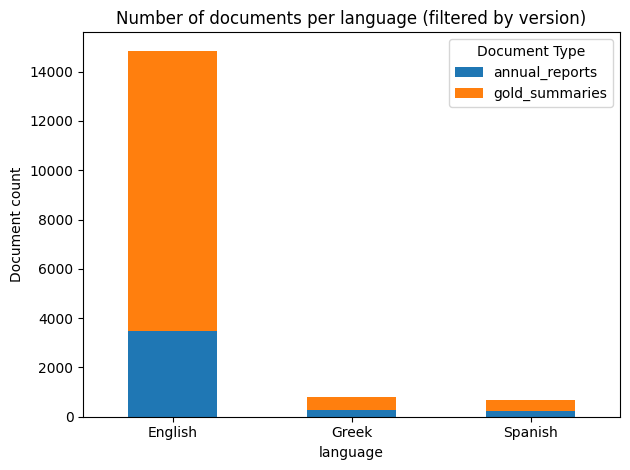

In [5]:
# Count documents by language and doc_type
counts = (
    df
    .groupby(['language', 'doc_type'])
    .size()
    .unstack(fill_value=0)                                
)

# Plot stacked bar
counts.plot(kind='bar', stacked=True)
plt.title('Number of documents per language (filtered by version)')
plt.ylabel('Document count')
plt.xticks(rotation=0)
plt.legend(title='Document Type')
plt.tight_layout()
plt.show()

In [6]:
# Filter per language/version as you specified
fdf = df[
    (pd.isna(df['version'])) |
    ((df['language'] == 'English') & (df['version'] == '1')) |
    ((df['language'] == 'Greek') & (df['version'] == '2')) |
    ((df['language'] == 'Spanish') & (df['version'] == 'GS1'))
]

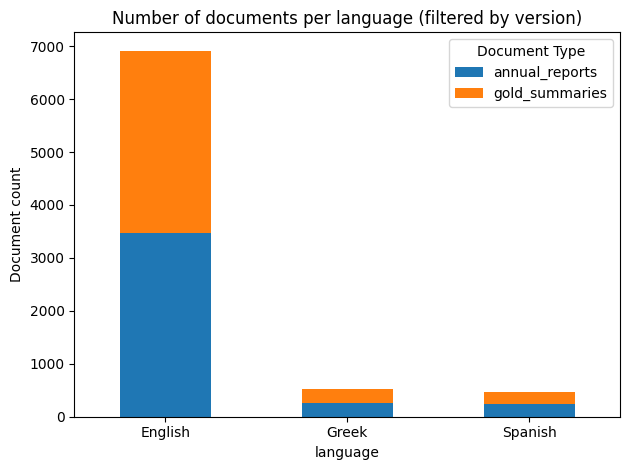

In [7]:
# Count documents by language and doc_type
counts = (
    fdf
    .groupby(['language', 'doc_type'])
    .size()
    .unstack(fill_value=0)                                
)

# Plot stacked bar
counts.plot(kind='bar', stacked=True)
plt.title('Number of documents per language (filtered by version)')
plt.ylabel('Document count')
plt.xticks(rotation=0)
plt.legend(title='Document Type')
plt.tight_layout()
plt.show()


In [11]:
''.join(list("thuis is a tesdt"))

'thuis is a tesdt'

In [ ]:
fdf['text'].head().apply(lambda x: nlp(x))

0    [ , R, e, g, i, s, t, e, r, e, d,  , o, f, f, ...
1    [ , M, e, d, i, t, e, r, r, a, n, e, a, n,  , ...
2    [ , M, e, d, i, t, e, r, r, a, n, e, a, n,  , ...
3    [ , A, N, N, U, A, L,  , R, E, P, O, R, T,  , ...
4    [ , M, E, G, G, I, T, T,  , P, L, C,  ,  ,  , ...
Name: text, dtype: object

array([[<Axes: title={'center': 'English'}>,
        <Axes: title={'center': 'Greek'}>],
       [<Axes: title={'center': 'Spanish'}>, <Axes: >]], dtype=object)

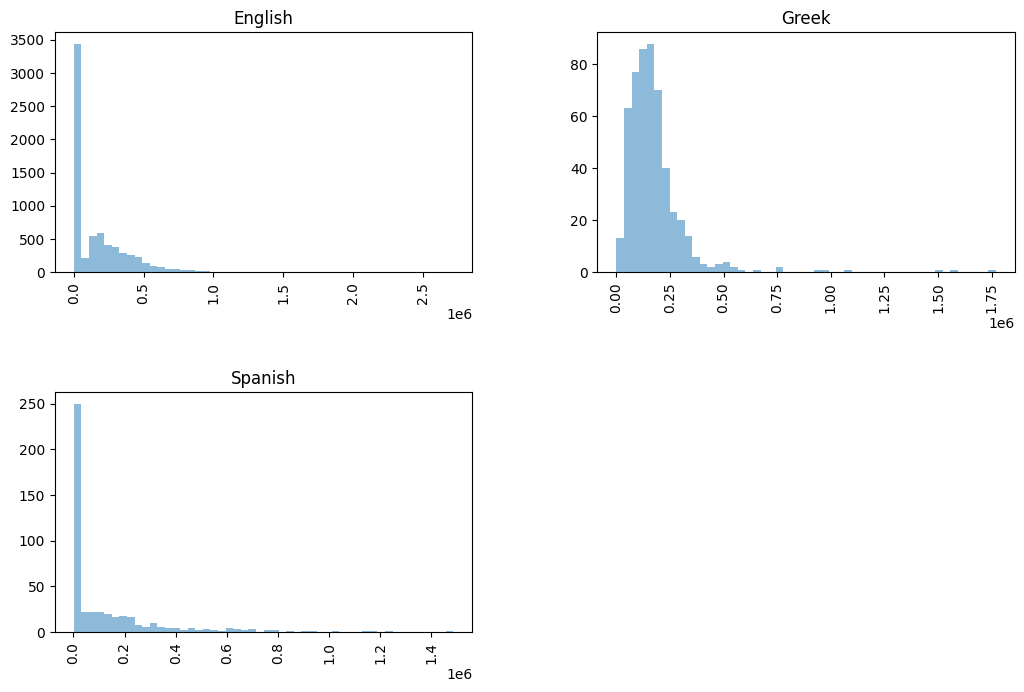

In [25]:
fdf['text'].str.len().hist(by=fdf['language'], bins=50, figsize=(12, 8), alpha=0.5)

### Evaluation results

In [30]:
en = pd.read_csv('results/English.csv')  # ver: _1
gr = pd.read_csv('results/Greek.csv')  # ver: _2
es = pd.read_csv('results/Spanish.csv')  # ver: _GS1
dfs = [en, gr, es]
languages = ['English', 'Greek', 'Spanish']

In [36]:
for df in dfs:
    df['variant_type'] = df['variant']
    df.loc[df['variant'].str.endswith(SUMMARY_VER), 'variant_type'] = 'random_summary'
    df.loc[:, 'noise_percentage'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[-3:]
    df.loc[df['variant_type'] == 'source', 'noise_percentage'] = '0.0'
    df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[:-4]

In [44]:
df = df[df['noise_percentage'] != 'GS1']

In [58]:
df.head()

,source_doc,eval_type,eval_method,variant,score,duration,variant_type,noise_percentage
0,1,N-gram,Rouge1,source,1.00000,0.015711,source,0.0
1,1,N-gram,Rouge2,source,1.00000,0.008005,source,0.0
2,1,Graph-based,AutoSummENG,source,1.00000,0.283234,source,0.0
3,1,Graph-based,MeMoG,source,1.00000,0.283234,source,0.0
4,1,Meta,NPowER,source,0.88824,0.283234,source,0.0


In [59]:
en.variant_type.value_counts()

variant_type
100                            800
consecutively_swapped_words    400
deleted_words                  400
inserted_sentence              400
randomly_swapped_words         400
removed_sentence               400
repeated_sentence              400
source                          80
Name: count, dtype: int64

In [67]:
en.loc[(en['variant_type'] == 'deleted_words') & (df['eval_method'] == 'Rouge2'),  ['noise_percentage', 'score']].corr(method='spearman')

,noise_percentage,score
noise_percentage,1.000000,-0.516748
score,-0.516748,1.000000


#### Randomly swapped words

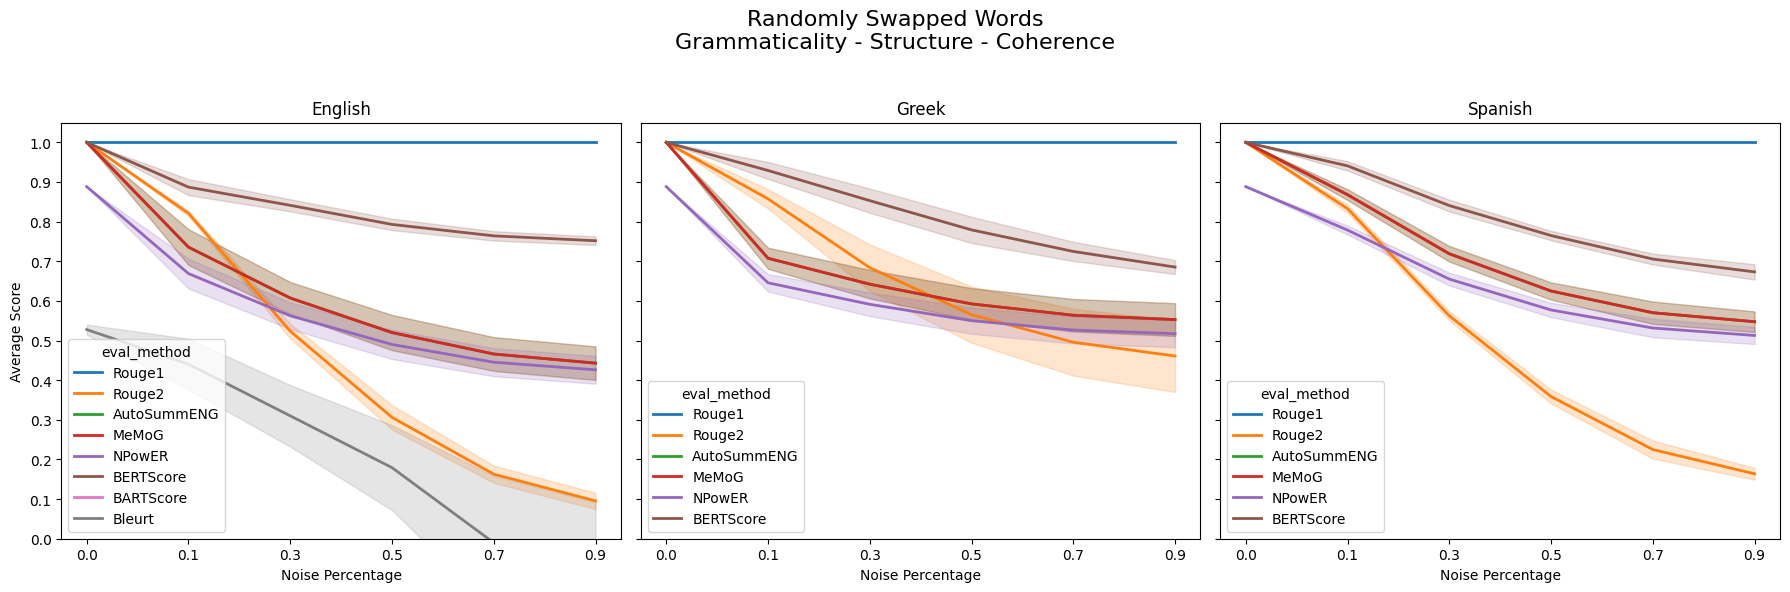

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method', 
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Randomly Swapped Words\nGrammaticality - Structure - Coherence', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Consecutively swapped words

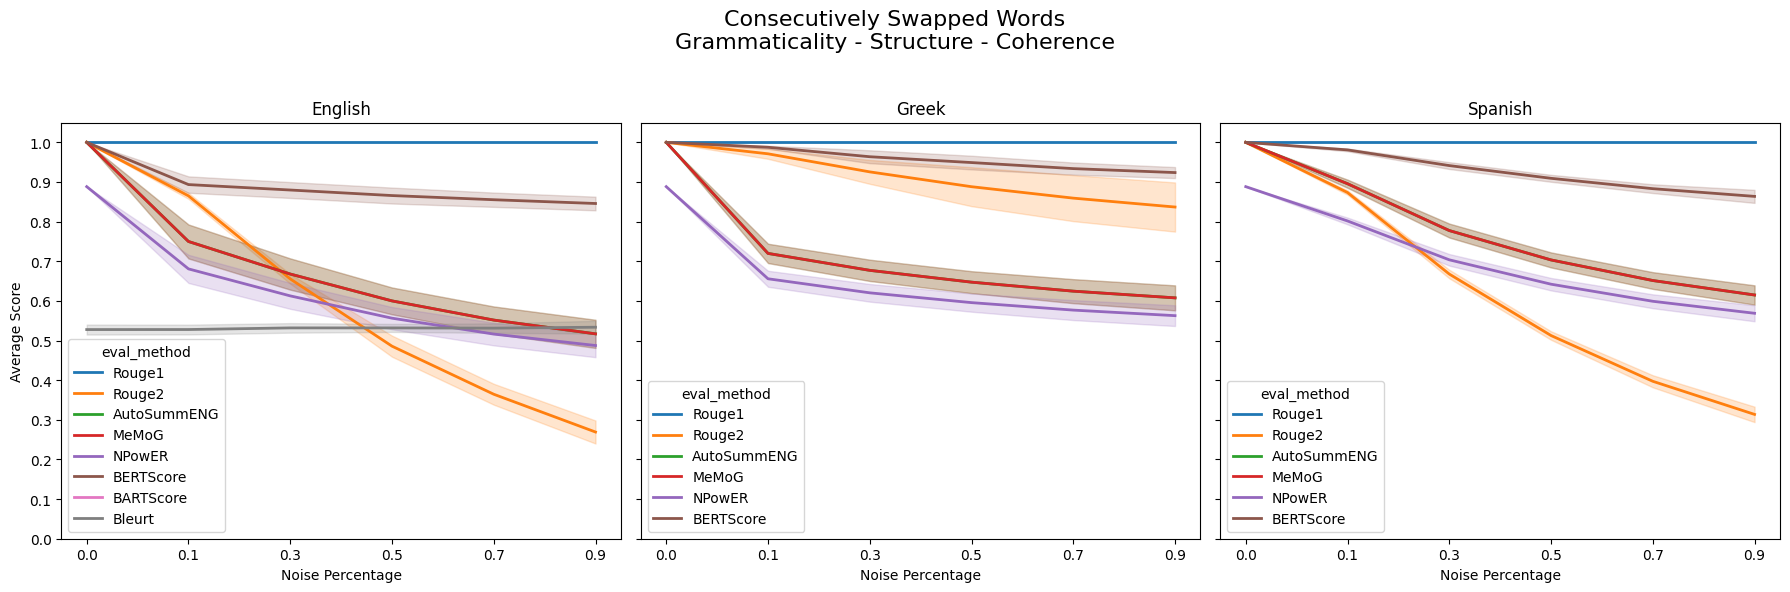

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method', 
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Consecutively Swapped Words\nGrammaticality - Structure - Coherence', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Removed words

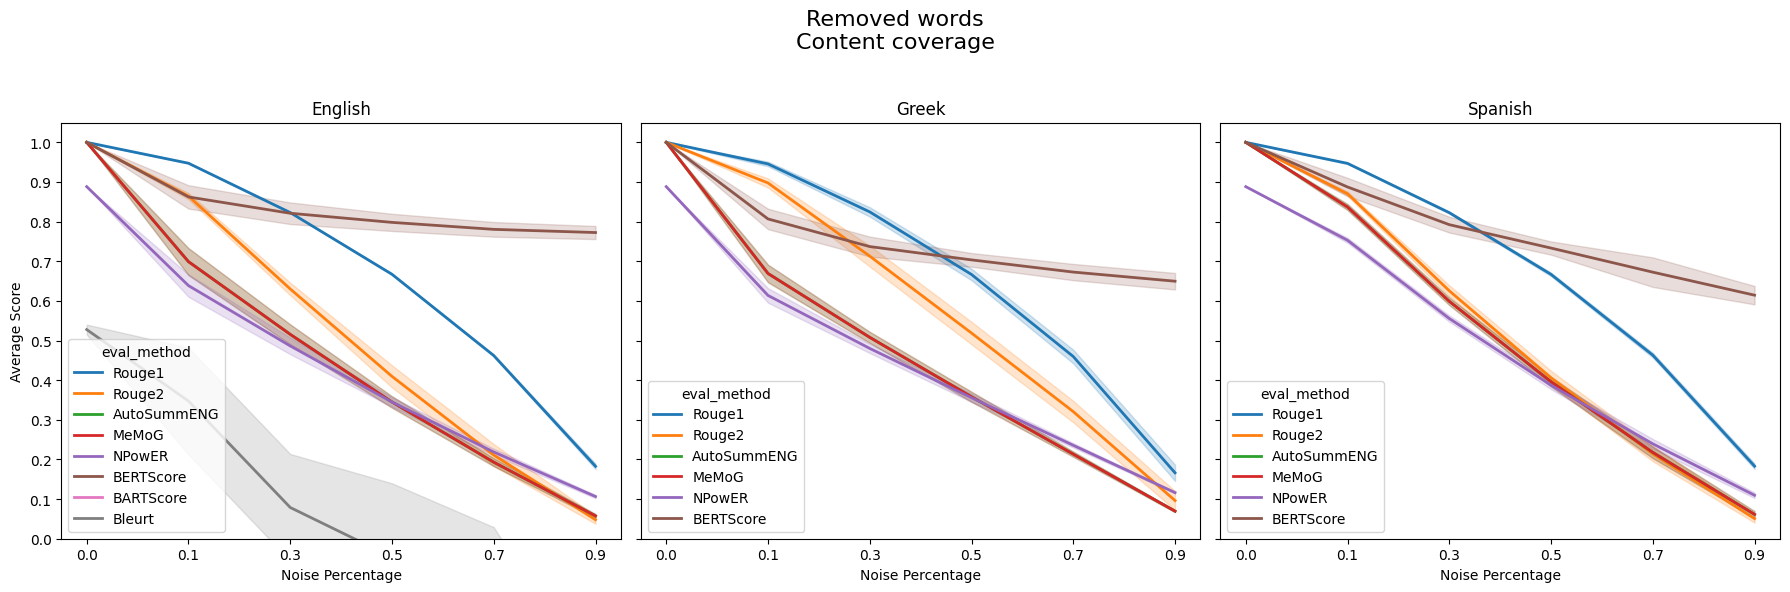

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method', 
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Removed words\nContent coverage', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Removed sentence

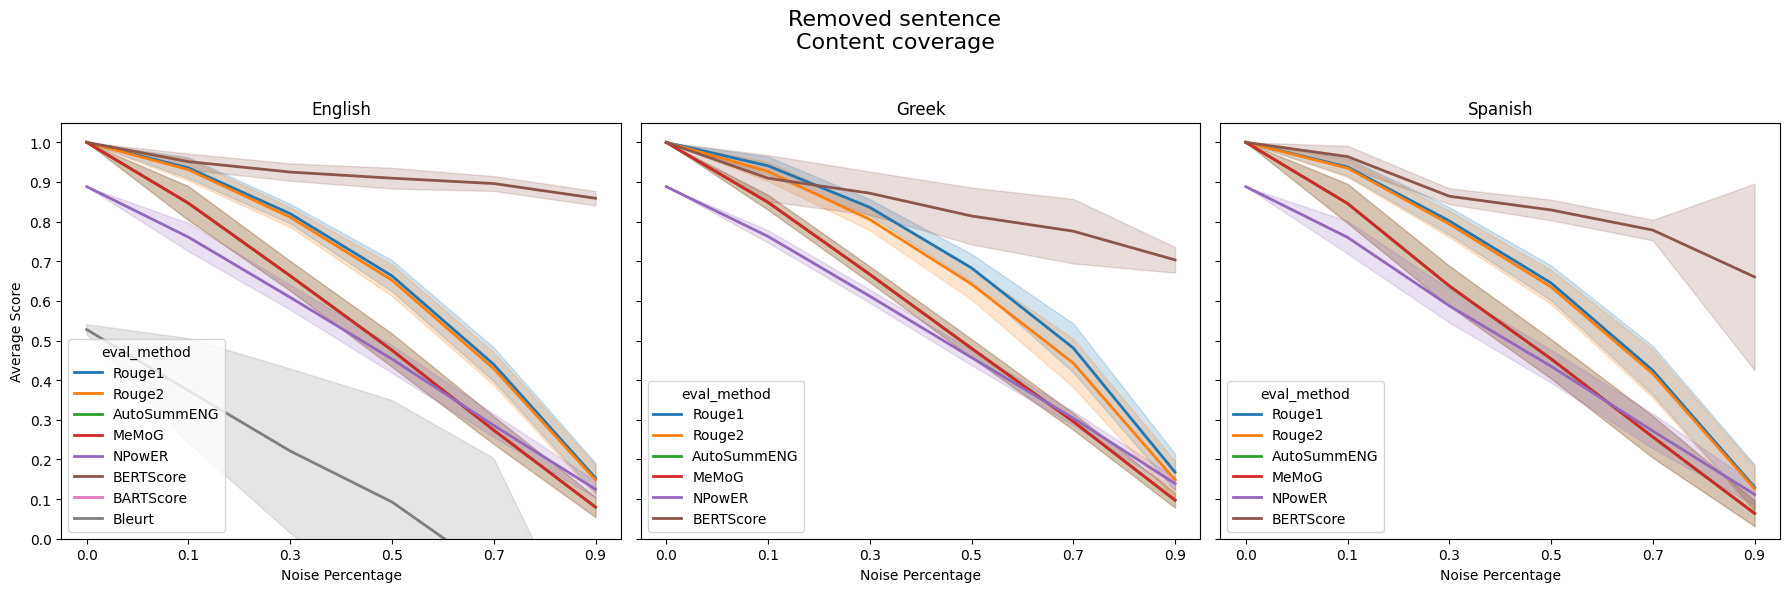

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method', 
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Removed sentence\nContent coverage', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Inserted sentence

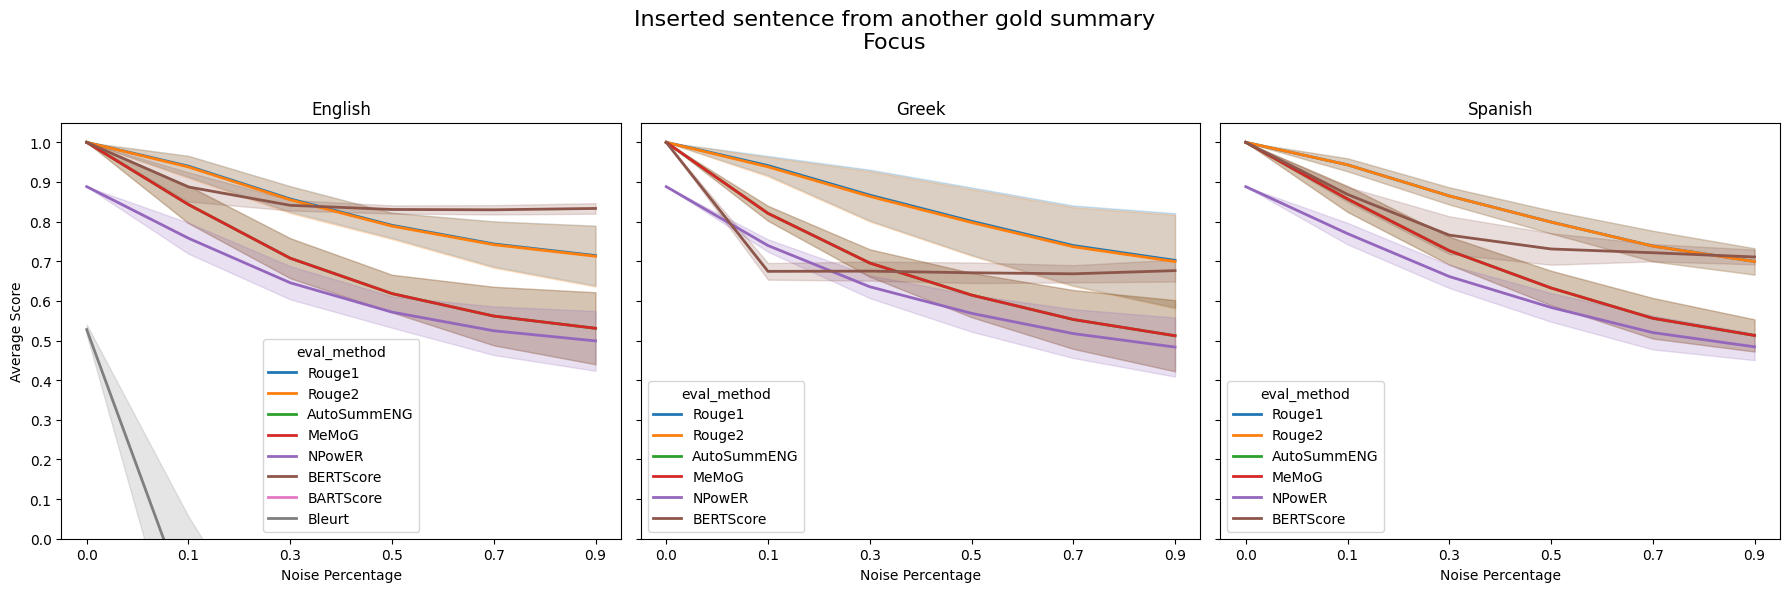

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method',
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Inserted sentence from another gold summary\nFocus', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Repeated sentence

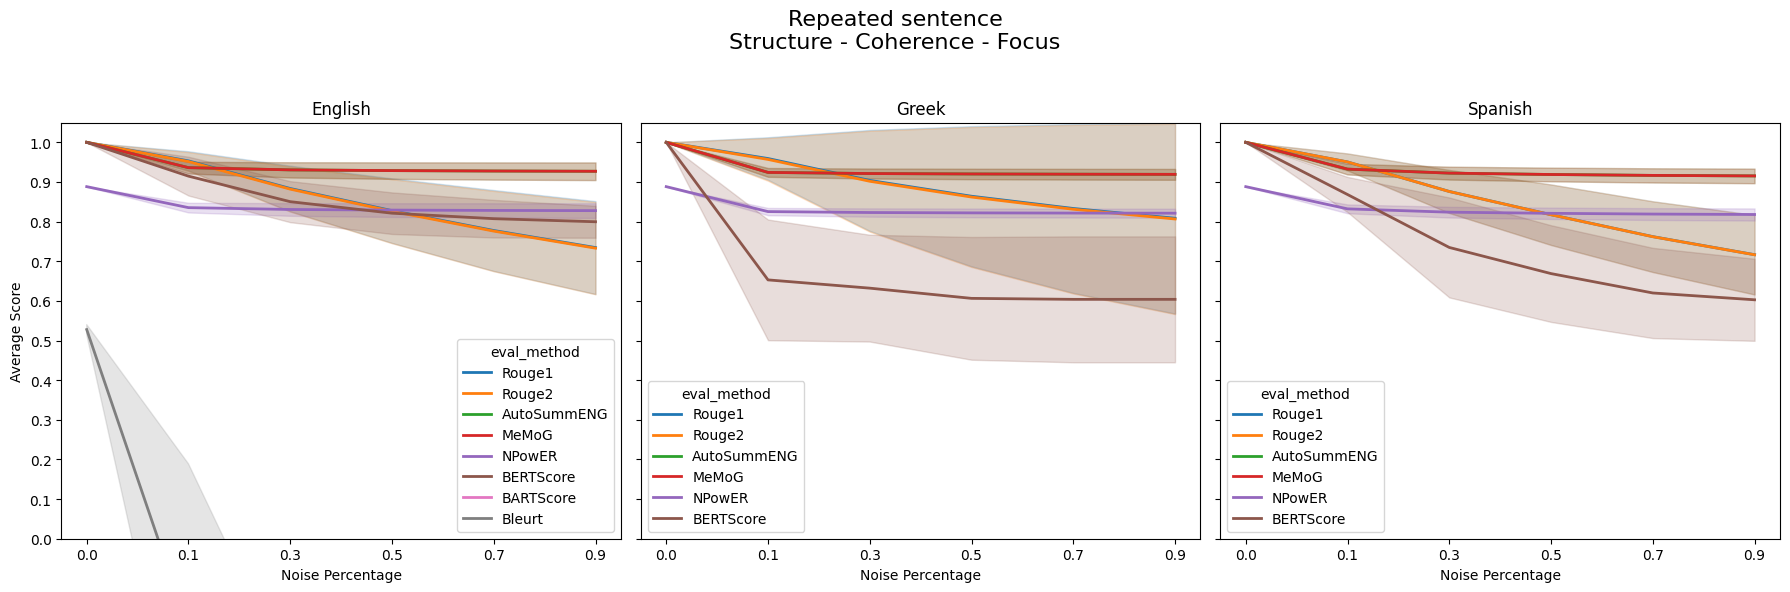

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, df, lang in zip(axes, dfs, languages):

    sns.lineplot(
        data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')],
        x='noise_percentage', 
        y='score',
        hue='eval_method', 
        linewidth=2, 
        estimator=np.mean,
        errorbar='sd',
        ax=ax
    )
    
    ax.set_title(f'{lang}')
    ax.set_xlabel('Noise Percentage')
    ax.set_ylabel('Average Score' if lang == 'English' else '')  # Only left plot shows y label
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0.0, 1.1, step=0.1))

fig.suptitle('Repeated sentence\nStructure - Coherence - Focus', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

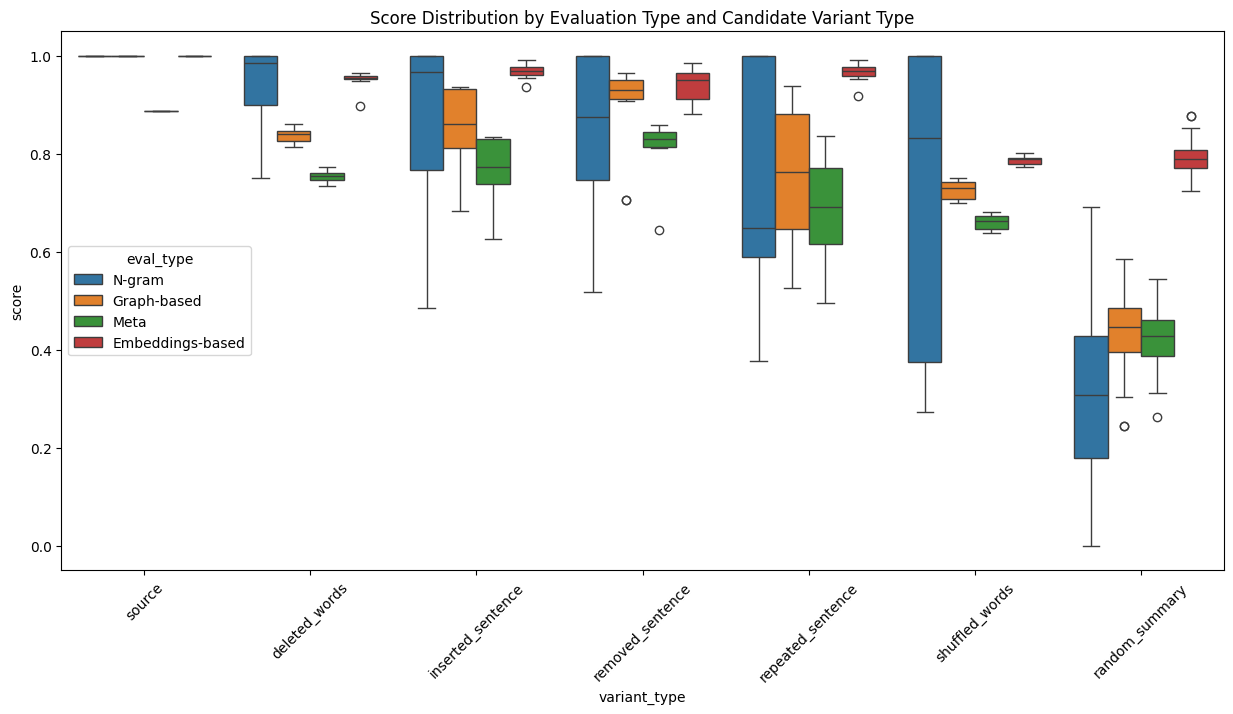

In [87]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='variant_type', y='score', hue='eval_type')
plt.title('Score Distribution by Evaluation Type and Candidate Variant Type')
plt.xticks(rotation=45)
plt.show()

In [48]:
df_summary = df.groupby(['eval_type', 'variant_type'])['score'].describe().reset_index().drop(columns='count')

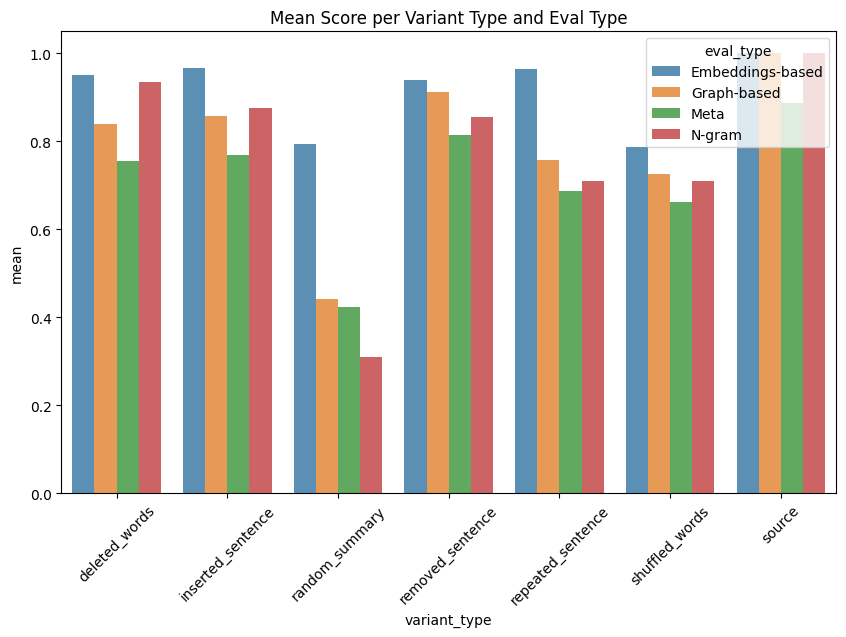

In [88]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_summary, x='variant_type', y='mean', hue='eval_type', alpha=0.8, errorbar=None)
plt.title('Mean Score per Variant Type and Eval Type')
plt.xticks(rotation=45)
plt.show()